In [2]:
import pandas as pd

accidentes = pd.read_csv("Datos/csv/accidentes.csv", parse_dates=["TW"])
clima = pd.read_csv("Datos/csv/clima.csv", parse_dates=["TW"])
raw = pd.read_csv("Datos/csv/raw_accidentes.csv", parse_dates=["TW"])

C:\Users\camil\AppData\Local\Temp\ipykernel_16432\2587534204.py:5: DtypeWarning: Columns (0: RADICADO, 1: MES_NOMBRE) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv("Datos/csv/raw_accidentes.csv", parse_dates=["TW"])


In [4]:
filas_summary_null = clima[clima["summary"].isnull()]
filas_summary_null.isnull().mean().sort_values(ascending=False) * 100

summary                100.000000
icon                   100.000000
precipIntensity         99.773987
precipProbability       99.773987
windBearing             20.990593
windSpeed                5.977133
cloudCover               1.449035
visibility               0.781932
uvIndex                  0.780109
humidity                 0.166776
temperature              0.111184
apparentTemperature      0.111184
dewPoint                 0.055592
TW                       0.000000
BARRIO                   0.000000
dtype: float64

In [5]:
clima=clima.dropna(subset=["summary"])



In [8]:
print("Valores únicos de summary:")
print(clima["summary"].unique())
print("")
print("")
print("")
print("Valores únicos de icon:")
print(clima["icon"].unique())

Valores únicos de summary:
<StringArray>
[                'Partly Cloudy',                         'Foggy',
                 'Mostly Cloudy',                         'Clear',
                      'Overcast',                       'Drizzle',
                    'Light Rain',                          'Rain',
                    'Heavy Rain',              'Possible Drizzle',
           'Possible Light Rain',       'Windy and Mostly Cloudy',
       'Humid and Mostly Cloudy',            'Humid and Overcast',
       'Windy and Partly Cloudy',                         'Windy',
                'Rain and Windy',                         'Humid',
 'Possible Light Rain and Windy',       'Humid and Partly Cloudy']
Length: 20, dtype: str



Valores únicos de icon:
<StringArray>
['partly-cloudy-night',                 'fog',   'partly-cloudy-day',
           'clear-day',              'cloudy',         'clear-night',
                'rain',                'wind']
Length: 8, dtype: str


In [9]:
clima=clima.drop(columns=["icon"])

In [11]:
mask = clima["windBearing"].isnull()
nulos = clima.loc[mask].isnull().sum()
porcentaje = (clima.loc[mask].isnull().mean() * 100).round(2)

pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje}).sort_values("Porcentaje (%)", ascending=False)

,Nulos,Porcentaje (%)
windBearing,917350,100.0
TW,0,0.0
summary,0,0.0
precipIntensity,0,0.0
precipProbability,0,0.0
BARRIO,0,0.0
temperature,0,0.0
apparentTemperature,0,0.0
humidity,0,0.0
dewPoint,0,0.0


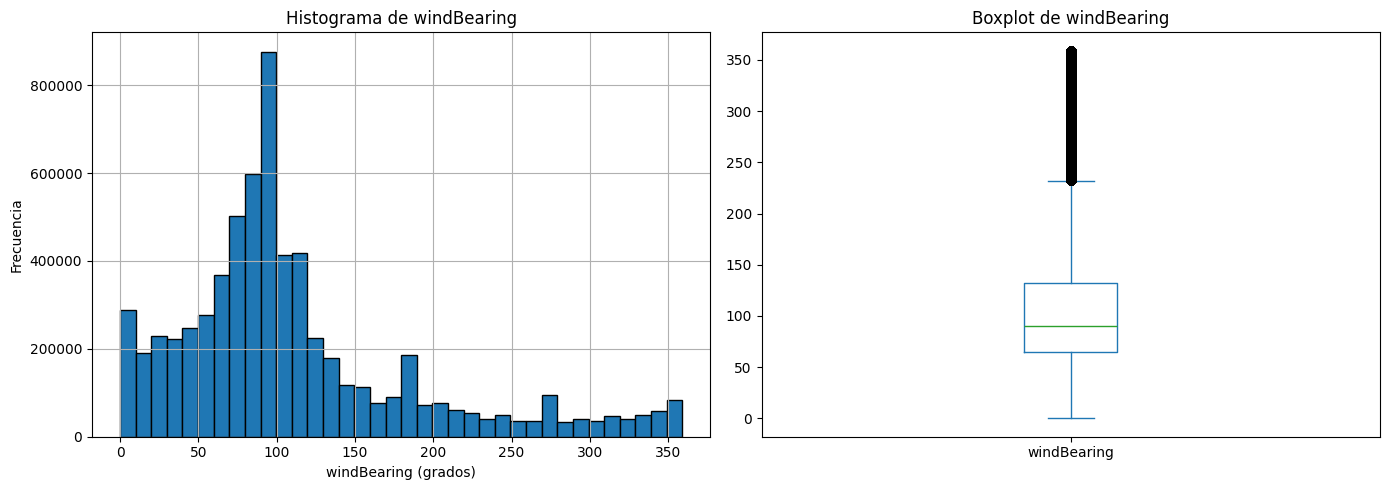

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clima["windBearing"].dropna().hist(bins=36, ax=axes[0], edgecolor="black")
axes[0].set_title("Histograma de windBearing")
axes[0].set_xlabel("windBearing (grados)")
axes[0].set_ylabel("Frecuencia")

clima["windBearing"].dropna().plot.box(ax=axes[1])
axes[1].set_title("Boxplot de windBearing")

plt.tight_layout()
plt.show()

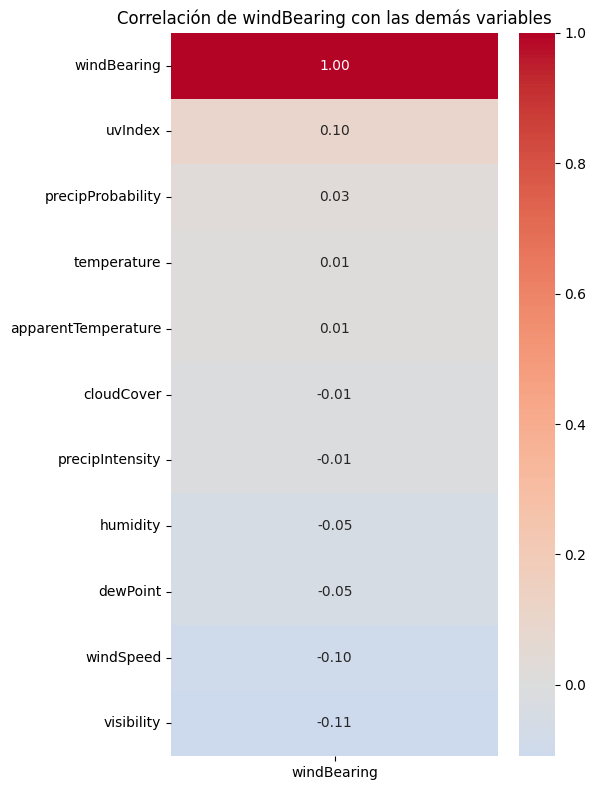

In [14]:
import seaborn as sns

numericas = clima.select_dtypes(include="number")
corr = numericas.corr()[["windBearing"]].sort_values("windBearing", ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación de windBearing con las demás variables")
plt.tight_layout()
plt.show()

In [17]:
numericas = clima.select_dtypes(include="number")

Q1 = numericas.quantile(0.25)
Q3 = numericas.quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

out_inf = (numericas < lim_inf).sum()
out_sup = (numericas > lim_sup).sum()
total_out = out_inf + out_sup
porcentaje = (total_out / numericas.count() * 100).round(2)

resumen = pd.DataFrame({
    "Límite inferior": lim_inf.round(2),
    "Outliers (inf)": out_inf,
    "Límite superior": lim_sup.round(2),
    "Outliers (sup)": out_sup,
    "Total outliers": total_out,
    "Porcentaje (%)": porcentaje
}).sort_values("Total outliers", ascending=False)

resumen

,Límite inferior,Outliers (inf),Límite superior,Outliers (sup),Total outliers,Porcentaje (%)
precipIntensity,-0.91,0,1.52,775226,775226,10.42
windBearing,-35.50,0,232.50,628161,628161,9.63
windSpeed,-1.09,0,3.95,331107,331107,4.45
precipProbability,-0.39,0,0.65,327735,327735,4.40
humidity,0.35,74130,1.15,0,74130,1.00
dewPoint,8.67,33429,20.08,13928,47357,0.64
visibility,1.89,32790,23.53,0,32790,0.44
uvIndex,-6.00,0,10.00,24015,24015,0.32
cloudCover,0.06,13349,1.42,0,13349,0.18
temperature,8.39,288,30.82,1731,2019,0.03


In [18]:
for i in numericas:
    print(i)
    print("Promedio:", clima[i].mean())
    print("Mediana:", clima[i].median())
    print()

precipIntensity
Promedio: 0.4762236046915152
Mediana: 0.0303

precipProbability
Promedio: 0.15961656231329283
Mediana: 0.06

temperature
Promedio: 19.58553320312841
Mediana: 18.55

apparentTemperature
Promedio: 19.660351757504465
Mediana: 18.65

dewPoint
Promedio: 14.324304836978055
Mediana: 14.4

humidity
Promedio: 0.7363180346356558
Mediana: 0.74

windSpeed
Promedio: 1.5148264892003225
Mediana: 1.33

windBearing
Promedio: 110.64089828831426
Mediana: 90.0

cloudCover
Promedio: 0.7297193589962515
Mediana: 0.75

uvIndex
Promedio: 2.0078199533825716
Mediana: 0.0

visibility
Promedio: 11.462619801538033
Mediana: 10.003

